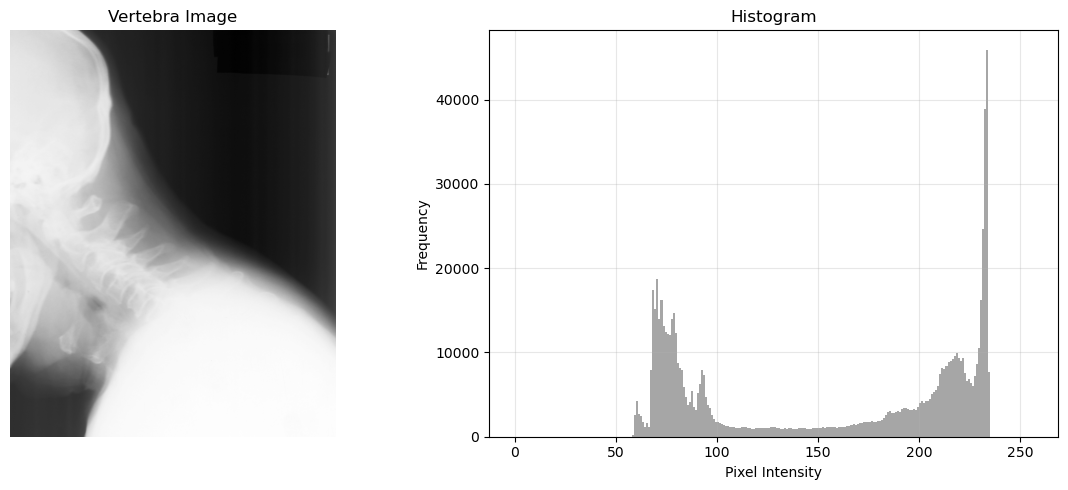

Image shape: (998, 800)
Image dtype: uint8
Min pixel value: 57
Max pixel value: 235


In [1]:
# 1.Start by reading the image and inspect the histogram. Is it a bimodal histogram? 
# Do you think it will be possible to segment it so only the bones are visible?
import skimage.io as io
import skimage.color as color
import matplotlib.pyplot as plt
import numpy as np

image = io.imread('data/vertebra.png')

# Display the image
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Vertebra Image')
plt.axis('off')

# Display the histogram
plt.subplot(1, 2, 2)
plt.hist(image.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")
print(f"Min pixel value: {image.min()}")
print(f"Max pixel value: {image.max()}")

In [4]:
# 3.
from skimage.util import img_as_float
from skimage.util import img_as_ubyte

image = io.imread('data/vertebra.png')
image_float = img_as_float(image)

print("Image min (float):", image_float.min())
print("Image max (float):", image_float.max())
print ("Normal min: ", image.min())
print ("Normal max: ", image.max())

Image min (float): 0.22352941176470587
Image max (float): 0.9215686274509803
Normal min:  57
Normal max:  235


In [5]:
# 4. 
from_float = img_as_ubyte(image_float)
print("From float min:", from_float.min())
print("From float max:", from_float.max())

From float min: 57
From float max: 235


# Histogram stretching

You should implement a function, that automatically stretches the histogram of an image. In other words, the function should create a new image, where the pixel values are changed so the histogram of the output image is *optimal*. Here *optimal* means, that the minimum value is 0 and the maximum value is 255. It should be based on the *linear histogram stretching* equation:

$$g(x,y) =\frac{v_\text{max,d}-v_\text{min,d}}{v_\text{max}-v_\text{min}}(f(x,y) - v_\text{min} )+v_\text{min,d} \enspace .$$

Here $f(x,y)$ is the input pixel value and  $g(x,y)$ is the output pixel value, $v_\text{max,d}$ and $v_\text{min,d}$ are the desired minimum and maximum values (0 and 255) and  $v_\text{max}$ and $v_\text{min}$ are the current minumum and maximum values.

**Exercise 5:** *Implement a Python function called `histogram_stretch`. It can, for example, follow this example:*

In [6]:
# 5.
def histogram_stretch(img_in):
    """
    Stretches the histogram of an image 
    :param img_in: Input image
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
    min_val = img_float.min()
    max_val = img_float.max()
    min_desired = 0.0
    max_desired = 1.0
	
    # Apply linear histogram stretching equation:
    # g(x,y) = (v_max_d - v_min_d) / (v_max - v_min) * (f(x,y) - v_min) + v_min_d
    img_out = ((max_desired - min_desired) / (max_val - min_val)) * (img_float - min_val) + min_desired

    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)

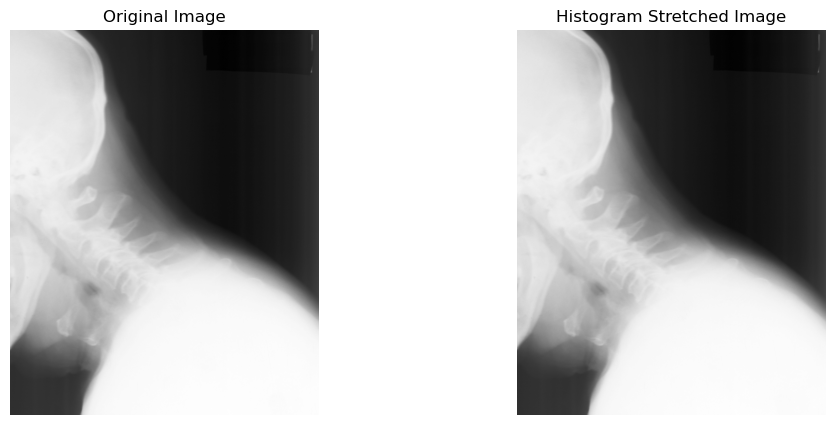

In [9]:
# 6. 
image = io.imread('data/vertebra.png')
stretched_image = histogram_stretch(image)
# Display the original and stretched images
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(stretched_image, cmap='gray')
plt.title('Histogram Stretched Image')
plt.axis('off')
plt.show()


# Non-linear pixel value mapping

The goal is to implement and test a function that performs a $\gamma$-mapping of pixel values:

$$g(x,y) = f(x,y)^\gamma \enspace .$$

You can use the *Numpy* function `power` to compute the actual mapping function. 

**Exercise 7:** *Implement a function, `gamma_map(img, gamma)`, that:*

1. Converts the input image to float
2. Do the gamma mapping on the pixel values
3. Returns the resulting image as an unsigned byte image.

In [10]:
# 7.

def gamma_map(img, gamma):
    """
    Applies a gamma mapping to the input image.
    :param img: Input image
    :param gamma: Gamma value for the mapping
    :return: Image after applying gamma mapping
    """
    # Convert the input image to float
    img_float = img_as_float(img)
    
    # Apply the gamma mapping
    img_gamma = np.power(img_float, gamma)
    
    # Convert back to unsigned byte
    return img_as_ubyte(img_gamma)

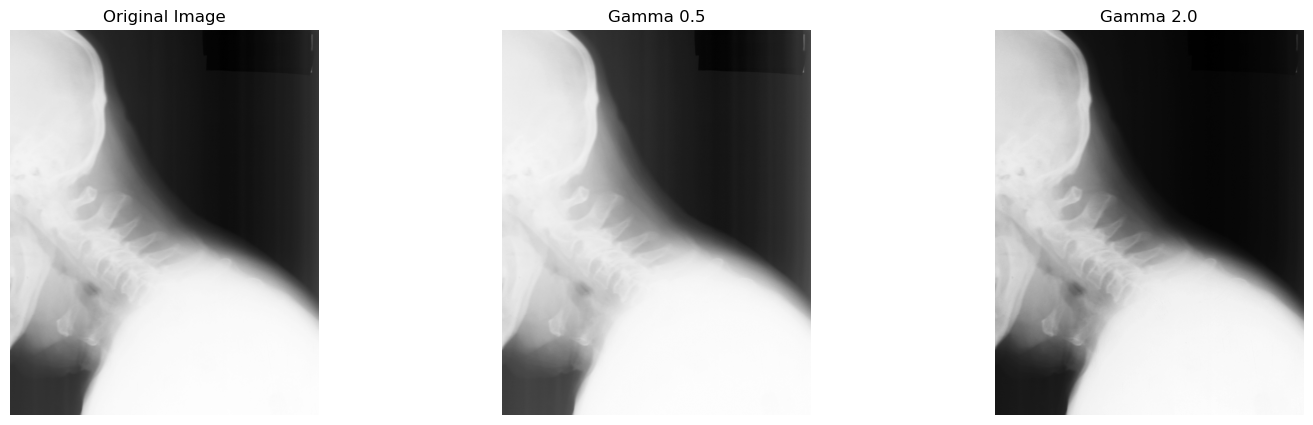

In [13]:
# 8.
image = io.imread('data/vertebra.png')
gamma_025 = gamma_map(image, 0.5)
gamma_2 = gamma_map(image, 2.0)
# Display the original and gamma-mapped images
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off') 
plt.subplot(1, 3, 2)
plt.imshow(gamma_025, cmap='gray')
plt.title('Gamma 0.5')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(gamma_2, cmap='gray')
plt.title('Gamma 2.0')
plt.axis('off')
plt.show()  


# Image segmentation by thresholding

Now we will try to implement some functions that can seperate an image into *segments*. In this exercise, we aim at seperating the *background* from the *foreground* by setting a threshold in a gray scale image or several thresholds in color images.

**Exercise 9:** *Implement a function, `threshold_image` :*

In [14]:
# 9. 
def threshold_image(img_in, thres):
    """
    Apply a threshold in an image and return the resulting image
    :param img_in: Input image
    :param thres: The treshold value in the range [0, 255]
    :return: Resulting image (unsigned byte) where background is 0 and foreground is 255
    """
    # Convert the input image to float
    img_float = img_as_float(img_in)
    thres_float = thres / 255.0  # Normalize threshold to [0, 1]
    
    # Apply the threshold
    img_out = np.where(img_float >= thres_float, 1.0, 0.0)
    
    # Convert back to unsigned byte
    return img_as_ubyte(img_out)

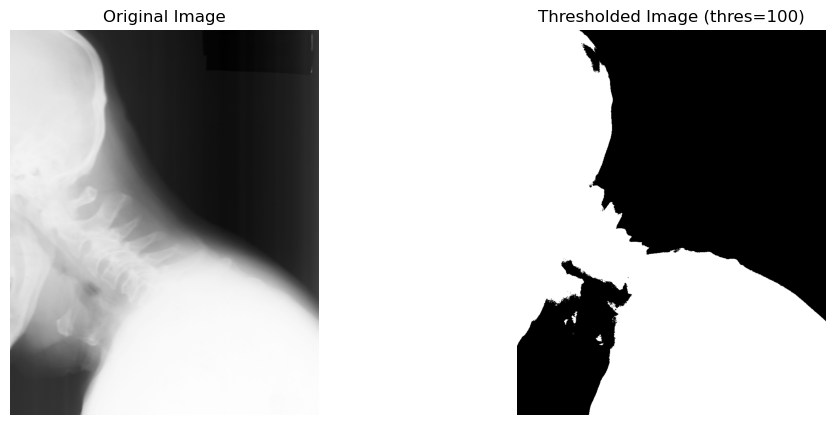

In [22]:
# 10.
image = io.imread('data/vertebra.png')
thresholded_image = threshold_image(image, 190)
# Display the original and thresholded images
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(thresholded_image, cmap='gray')
plt.title('Thresholded Image (thres=100)')
plt.axis('off')
plt.show()

In [23]:
# 11. use Otsu's method to find a suitable threshold value
from skimage.filters import threshold_otsu

image = io.imread('data/vertebra.png')
thresh = threshold_otsu(image)
binary = image > thresh
print("Otsu's threshold value:", thresh)

Otsu's threshold value: 148


In [ ]:
# 12. 
